# Reporte Anualizado de Ventas - E-Commerce


## Resumen Ejecutivo

Por indicación de dirección se pretende realizar el plan de trabajo para los ultimos 2Q del 2026 y para ello se realizo la labor de generar la base de datos sobre las ventas que se tuvieron en el periodo de "Enero 2025 - Agosto 2026".

# Planteamiento del problema

## Contexto Empresarial

Empresa E-Commerce cuenta con ventas sostenibles a nivel nacional, con el requerimiento de brindar un cierto orden para potenciar la estructura actual con una estrategia sostenible y escalable.

## Objeto de negocio

Por requerimientos internos y para fines de análisis y desarrollo del plan de trabajo para los Q3 y Q4, la empresa desea obtener un reporte sobre sus ventas a lo largo del año.

Dentro de este reporte se pretende obtener los siguientes puntos:

* Reporte de ventas anuales por mes
* Conocer cual fue el canal de ventas con mejores rendimientos en el transcurso del año

Con base a los objetivos previamente fijados, se procedera a realizar el reporte. En caso de surgir requerimientos adicionales se estaran desarrollando en proyectos futuros.

## Datos disponibles

* **Dataset:** 885 registros
* **Periodo:** Enero 2025 - Agosto 2026
* **Canales de venta:** 3039, 2917, 2814, 2808

## Paso 1 - Carga inicial de datos

### 1.1 Carga de librerias

In [63]:
# Se porcede a cargar las librerias para el análisis de datos

import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from functools import reduce
import scipy.stats as stats
import datetime as dt

### 1.2 Se importan los datos

In [64]:
# Se procede a cargar el DF para iniciar con el trabajo del anáilis:

df_ventas = pd.read_csv('/content/Ventas-colchones-2025-2026.csv')

## Paso 2.0 Preparación y limpieza de datos

### 2.1 Visualización inicial de los datos

Se procedera a abrir y visualizar cada DF por separado, una vez visualizado, se generarar las correcciones, cambios y pasos necesarios tales como limpieza, verificación de datos nulos, duplicados para así poder generar un análisis mas completo y acercado a los objetivos del proyecto.

In [65]:
# Se realiza la visualización inicial de los datos

df_ventas.info()
print(' ')
print(' ')
print('-------------')
print(' ')
print(' ')
df_ventas.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Movimiento     885 non-null    object 
 1   Fecha Emisión  885 non-null    object 
 2   Cliente        885 non-null    int64  
 3   Artículo       885 non-null    object 
 4   Cantidad       885 non-null    int64  
 5   Precio Total   885 non-null    float64
 6   Descuentos     885 non-null    int64  
 7   Sub Total      885 non-null    float64
 8   Precio6        885 non-null    float64
 9   Total          885 non-null    float64
dtypes: float64(4), int64(3), object(3)
memory usage: 69.3+ KB
 
 
-------------
 
 


,Movimiento,Fecha Emisión,Cliente,Artículo,Cantidad,Precio Total,Descuentos,Sub Total,Precio6,Total
0,Pedido 11167,1/6/2025,2808,67000,2,305.689655,0,305.689655,94.93,354.60
1,Pedido 11192,1/6/2025,2808,67224,3,691.137931,0,691.137931,161.21,801.72
2,Pedido 11217,1/13/2025,2814,67000,2,385.068966,0,385.068966,94.93,446.68
3,Pedido 11217,1/13/2025,2814,67000,26,3903.362069,0,3903.362069,94.93,4527.90
4,Pedido 11194,1/13/2025,2808,67224,1,403.189655,0,403.189655,161.21,467.70
5,Pedido 11225,1/15/2025,2814,67000,1,161.396552,0,161.396552,94.93,187.22
6,Pedido 11225,1/15/2025,2814,67000,1,88.853448,0,88.853448,94.93,103.07
7,Pedido 11225,1/15/2025,2814,67000,13,1951.681034,0,1951.681034,94.93,2263.95
8,Pedido 11225,1/15/2025,2814,67619,1,373.836207,0,373.836207,210.99,433.65
9,Pedido 11231,1/17/2025,2814,67000,1,150.129310,0,150.129310,94.93,174.15


Para fines de optimización durante el proceso del análisis y con los datos obtenidos en esta visualización inicial, se procedera a realizar las siguientes acciones:

* Tratamiento de encabezados de columnas
* Conversión de tipos de columnas a los tipos correctos
* Verificación de datos duplicados
* Verificación de datos nulos

Si bien, de momento los datos encontrados hasta el momento se encuentras limpios, es mejor realizar estas verificaciones para prevenir errores y adelantar pasos en el futuro.

#### 2.1.1 Tratamiento de encabezados de columnas

[Para fines practicos, los encabezados se pasaran a formato "snake_case"].

In [66]:
df_ventas.columns = df_ventas.columns.str.lower().str.replace(' ', '_')
df_ventas.head()

,movimiento,fecha_emisión,cliente,artículo,cantidad,precio_total,descuentos,sub_total,precio6,total
0,Pedido 11167,1/6/2025,2808,67000,2,305.689655,0,305.689655,94.93,354.60
1,Pedido 11192,1/6/2025,2808,67224,3,691.137931,0,691.137931,161.21,801.72
2,Pedido 11217,1/13/2025,2814,67000,2,385.068966,0,385.068966,94.93,446.68
3,Pedido 11217,1/13/2025,2814,67000,26,3903.362069,0,3903.362069,94.93,4527.90
4,Pedido 11194,1/13/2025,2808,67224,1,403.189655,0,403.189655,161.21,467.70


#### 2.1.2 Conversión de los tipos de columnas

[Se procedera a convertir los tipos de columnas actuales a los tipos de columnas correctos, según sea el caso:]

In [67]:
# Se procede a cambiar el tipo de la columna "fecha_emisión" al tipo de fecha

df_ventas['fecha_emisión'] = pd.to_datetime(df_ventas['fecha_emisión'])

# Se procede a cambiar el tipo de la columna "cliente" al tipo correcto

df_ventas['cliente'] = df_ventas['cliente'].astype('str')

# Se verifica que los cambios se hayan efectuado con exito:

df_ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   movimiento     885 non-null    object        
 1   fecha_emisión  885 non-null    datetime64[ns]
 2   cliente        885 non-null    object        
 3   artículo       885 non-null    object        
 4   cantidad       885 non-null    int64         
 5   precio_total   885 non-null    float64       
 6   descuentos     885 non-null    int64         
 7   sub_total      885 non-null    float64       
 8   precio6        885 non-null    float64       
 9   total          885 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 69.3+ KB


#### 2.1.3 Verificación de datos duplicados

[Se procede a realizar una investigación sobre la presenia de datos duplicados, en caso de existir se le dara el trato correspondiente, en caso de que no, se procedera a realizar la validación de datos nulos:]

In [68]:
# Se realiza la validación de la existencía de datos duplicados:

print('La cantidad de datos duplicados actuales es la siguiente:', df_ventas.duplicated().sum())


La cantidad de datos duplicados actuales es la siguiente: 46


[Al encontrar la presencía de datos duplicados, se procede a realizar su eliminación para evitar que la presencia de estos altere el reporte emanado de este reporte:]

In [69]:
# Se procede a eliminar los datos duplicados:

df_ventas = df_ventas.drop_duplicates()

# Se verifica que los cambios se hayan efectuado con exito:

print('La cantidad de datos duplicados actuales es la siguiente:', df_ventas.duplicated().sum())


La cantidad de datos duplicados actuales es la siguiente: 0


Una vez completado este paso se procede a verificar la existencía de datos nulos.

#### 2.1.4 Verificación de la existencia de datos nulos:

[Se procede a realizar la investigación de datos nulos en el DF, en caso de existir, por el tamaño del DF se valorara caso por caso para conocer los puntos en donde se encuentran estos y la relevancía que tienen con respecto al proyecto en cuestión. Dependiendo de la información resultante se valorara el tratamiendo idoneo sobre los mismos]

In [70]:
print("La cantidad de datos nulos encontrados al momento es la siguiente:")
print(df_ventas.isnull().sum())

La cantidad de datos nulos encontrados al momento es la siguiente:
movimiento       0
fecha_emisión    0
cliente          0
artículo         0
cantidad         0
precio_total     0
descuentos       0
sub_total        0
precio6          0
total            0
dtype: int64


### 2.2 Verificación de datos

[Al haber encontrado datos duplicados, se procedera a mostrar el resultado obtenidos al realiar la labor de limpieza de datos:]

In [71]:
df_ventas.info()
print(' ')
print(' ')
print('-------------')
print(' ')
print(' ')
df_ventas.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 0 to 884
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   movimiento     839 non-null    object        
 1   fecha_emisión  839 non-null    datetime64[ns]
 2   cliente        839 non-null    object        
 3   artículo       839 non-null    object        
 4   cantidad       839 non-null    int64         
 5   precio_total   839 non-null    float64       
 6   descuentos     839 non-null    int64         
 7   sub_total      839 non-null    float64       
 8   precio6        839 non-null    float64       
 9   total          839 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 72.1+ KB
 
 
-------------
 
 


,movimiento,fecha_emisión,cliente,artículo,cantidad,precio_total,descuentos,sub_total,precio6,total
0,Pedido 11167,2025-01-06,2808,67000,2,305.689655,0,305.689655,94.93,354.60
1,Pedido 11192,2025-01-06,2808,67224,3,691.137931,0,691.137931,161.21,801.72
2,Pedido 11217,2025-01-13,2814,67000,2,385.068966,0,385.068966,94.93,446.68
3,Pedido 11217,2025-01-13,2814,67000,26,3903.362069,0,3903.362069,94.93,4527.90
4,Pedido 11194,2025-01-13,2808,67224,1,403.189655,0,403.189655,161.21,467.70
5,Pedido 11225,2025-01-15,2814,67000,1,161.396552,0,161.396552,94.93,187.22
6,Pedido 11225,2025-01-15,2814,67000,1,88.853448,0,88.853448,94.93,103.07
7,Pedido 11225,2025-01-15,2814,67000,13,1951.681034,0,1951.681034,94.93,2263.95
8,Pedido 11225,2025-01-15,2814,67619,1,373.836207,0,373.836207,210.99,433.65
9,Pedido 11231,2025-01-17,2814,67000,1,150.129310,0,150.129310,94.93,174.15


## Paso 3: Estudio y comprobación de datos

[Se procedera a estudiar y comprobar el contenido de cada columna, según sea el caso:]

### 3.1 Periodo de tiempo

[Se validara el periodo de tiempo de inicio a fin]

In [72]:
print('Fecha inicial:', df_ventas['fecha_emisión'].min())
print(' ')
print(' ')
print('-------------')
print(' ')
print(' ')
print('Fecha final:', df_ventas['fecha_emisión'].max())



Fecha inicial: 2025-01-06 00:00:00
 
 
-------------
 
 
Fecha final: 2026-08-18 00:00:00


[Se procedera a contabilizar la cantidad de ventas que hubo por mes:]

In [73]:
# Se generara una función que permita automatizar el calculo de las cantidad de ventas generadas a lo largo de los meses, iniciando por el mes de enero 2025 a Agosto 2026

def count_monthly_sales(df):
    # Extraer el mes y año de la columna 'fecha_emisión'
    df['mes_año'] = df['fecha_emisión'].dt.to_period('M')
    # Contar la cantidad de ventas por mes y ordenar por fecha
    monthly_sales = df['mes_año'].value_counts().sort_index()
    return monthly_sales

# Llamar a la función y mostrar el resultado
ventas_por_mes = count_monthly_sales(df_ventas)
print('Cantidad de ventas por mes:')
print(ventas_por_mes)

Cantidad de ventas por mes:
mes_año
2025-01    53
2025-02    63
2025-03    27
2025-04    23
2025-05    21
2025-06    21
2025-07    27
2025-08    17
2025-09    31
2025-10    49
2025-11    41
2025-12    23
2026-01    25
2026-02    33
2026-03    81
2026-04    61
2026-05    66
2026-06    69
2026-07    54
2026-08    54
Freq: M, Name: count, dtype: int64


[Se procede a graficar los resultados:]

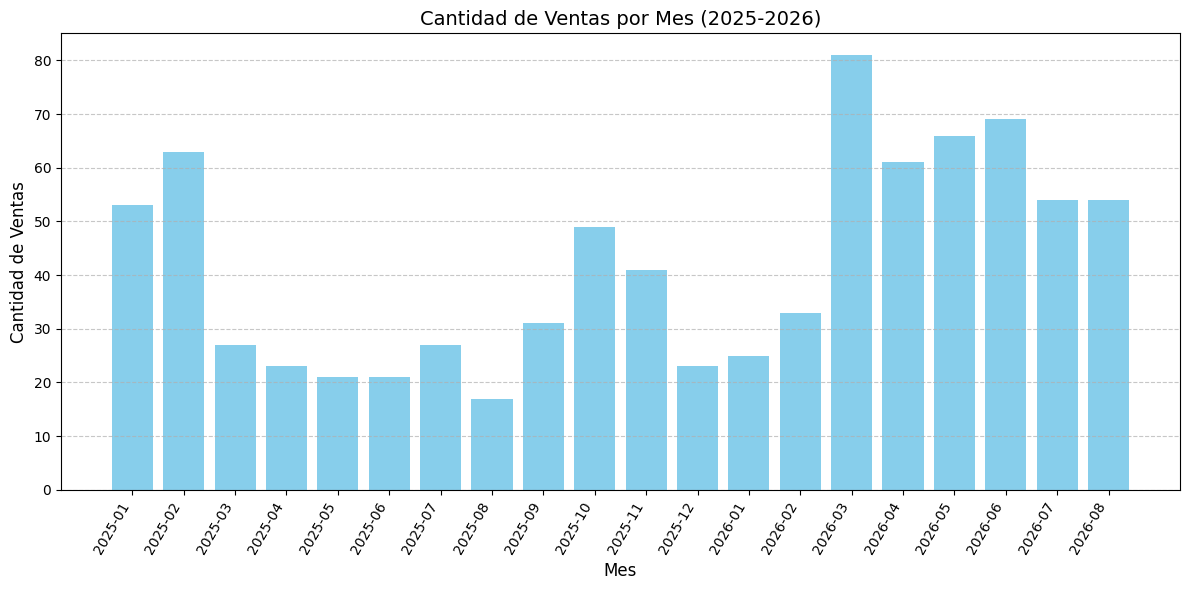

In [74]:
# Se genera grafica de barras utilizando los datos obtenidos de la cantidad de ventas en el mes con fines ilustrativos

plt.figure(figsize=(12, 6)) # Aumentar el tamaño de la figura para mejor visualización
plt.bar(ventas_por_mes.index.astype(str), ventas_por_mes.values, color='skyblue') # Convertir el índice a string y aplicar un color
plt.xlabel('Mes', fontsize=12) # Aumentar tamaño de fuente del label
plt.ylabel('Cantidad de Ventas', fontsize=12) # Aumentar tamaño de fuente del label
plt.title('Cantidad de Ventas por Mes (2025-2026)', fontsize=14) # Aumentar tamaño de fuente del título
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas y alinear a la derecha
plt.yticks(fontsize=10) # Aumentar tamaño de fuente de las etiquetas del eje y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir una cuadrícula sutil en el eje y
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

#### 3.1.1 Conclusiones de los resultados obtenidos

Con los resultados obtenidos al momento de segmentar la ventas obtenidas por mes a lo largo del tiempo, en una impresión inicial se puede percibir la siguiente información:

* **Frecuencía de ventas:** Los meses con mayor volumen de ventas suelesn ser los correspondientes al Q1 y al Q4, presentando una caida en el flujo de ventas en el mes de Diciembre, tomando como referencía el año 2025. No obstante, al reisar la frecuencia de ventas que hubo en el 2026, esta tendencia se revirtio, mostrando mayor volumen de ventas durante el Q2 y Q3, superando así mos meses correspondientes del ciclo pasado.

* **Preriodicidad y Festivos:** Durante el 2025, los meses con un desempeño no tan alentador fueron los meses correspondientes a "meses vacacionales" o "Verano", el producto comercializado en ese momento o la estrategía implementada no fueron los optimos para esas fechas, sin embargo, el plan de trabajo el cual se llevo acabo para las vacaciones de semana santa y fechas de vacaciones de verano fueron las optimas.

Estos son los comentarios vertidos hasta el momento, aun falta analizar más información para obtener resultados mas completos.

### 3.2 Canales de venta

Para antes de realizar la labor exaustiva de realizar el seguimiento detallado sobre el rendimiento y resultados obtenidos sobre cada canal de venta en especifico, se procedera a identificar los canales de ventas utilizados.

In [75]:
# Conteo de los canales de ventas, la columna utilizada como identificador del canal de venta es 'cliente'

print('La cantidad de canales de ventas utilizados fueron los siguientes:', df_ventas['cliente'].nunique())
print(' ')
print(' ')
print(' ')
print('-------------')
print(' ')
print(' ')
print('Los canales de ventas identificados son los siguientes:')
print(df_ventas['cliente'].unique())

La cantidad de canales de ventas utilizados fueron los siguientes: 4
 
 
 
-------------
 
 
Los canales de ventas identificados son los siguientes:
['2808' '2814' '2917' '3093']


Los canales de ventas utilizados desde el periodo de "Enero 2025" hasta Agosto 2026 fuero:

* 2808
* 2814
* 2917
* 3093

Una vez ya identificados, en los siguientes puntos se procedera a realizar el rastreo de ventas por cada canal junto con el rendimiento mensual y anual obtenidos de cada uno de ellos.

### 3.3 Productos vendidos

Como ultimo paso para la identificación de los datos con los cuales se procederan a alcanzar los objetivos del presente reporte, se procedera a identificar los productos vendidos en los periodos anteriormente mencionados, de esta manera se podra identificar si los resultados obtenidos durante los periodos vacacionales de 2026 tuvieron correlación con los productos manejados en ese momento o si bien fue otro factor el causante de ese incremento de ventas.

In [76]:
# Conteo e identificación de los productos disponibles, la columna "articulo" corresponde a este objetivo

print('La cantidad de productos disponibles fueron los siguientes:', df_ventas['artículo'].nunique())
print(' ')
print(' ')
print(' ')
print('-------------')
print(' ')
print(' ')
print('Los productos disponibles son los siguientes:')
print(df_ventas['artículo'].unique())

La cantidad de productos disponibles fueron los siguientes: 42
 
 
 
-------------
 
 
Los productos disponibles son los siguientes:
['67000' '67224' '67619' '67402' '67374' '67003' '67922' '67002' '67472'
 '67615' '67631' '67837' '67004' '75054' '67404' '67930' '67001' '67703'
 '69078' '67487' '75114' '67617' '6713H' '67226' '6713J' '6713F' '671BT'
 '671BS' '671BU' '67726' '69051' '69076' '69146' '6712Z' '67225' '67680'
 '67625' '6713N' '67699' '67682' '6713M' '6716Q']


Como se puede apreciar, en total existen 42 articulos disponibles para su venta.

Con la información obtenida hasta el momento se ha concluido la fase inicial del análisis exploratorio de datos (EDA), por ende, se procedera a generar los objetos de negocio.

## Paso 4.0 Objetivos de negocio

### 4.1 Reporte de ventas anual

En el siguiente punto se presentara el reporte de ventas de manera mensual, tanto las ventas globales, como por canal y por ultimo, por articulo.

#### 4.1.1 Visualización de Ventas totales a lo Largo del Tiempo (Gráfica de Barras)

La siguiente gráfica de barras muestra la evolución de las ventas mes a mes. Esto es útil para identificar tendencias, picos o caídas en el rendimiento.

In [77]:
# Se procede a mostrar las ventas que hubo por mes

ventas_por_mes = count_monthly_sales(df_ventas)
print('Cantidad de ventas por mes:')
print(ventas_por_mes)

Cantidad de ventas por mes:
mes_año
2025-01    53
2025-02    63
2025-03    27
2025-04    23
2025-05    21
2025-06    21
2025-07    27
2025-08    17
2025-09    31
2025-10    49
2025-11    41
2025-12    23
2026-01    25
2026-02    33
2026-03    81
2026-04    61
2026-05    66
2026-06    69
2026-07    54
2026-08    54
Freq: M, Name: count, dtype: int64


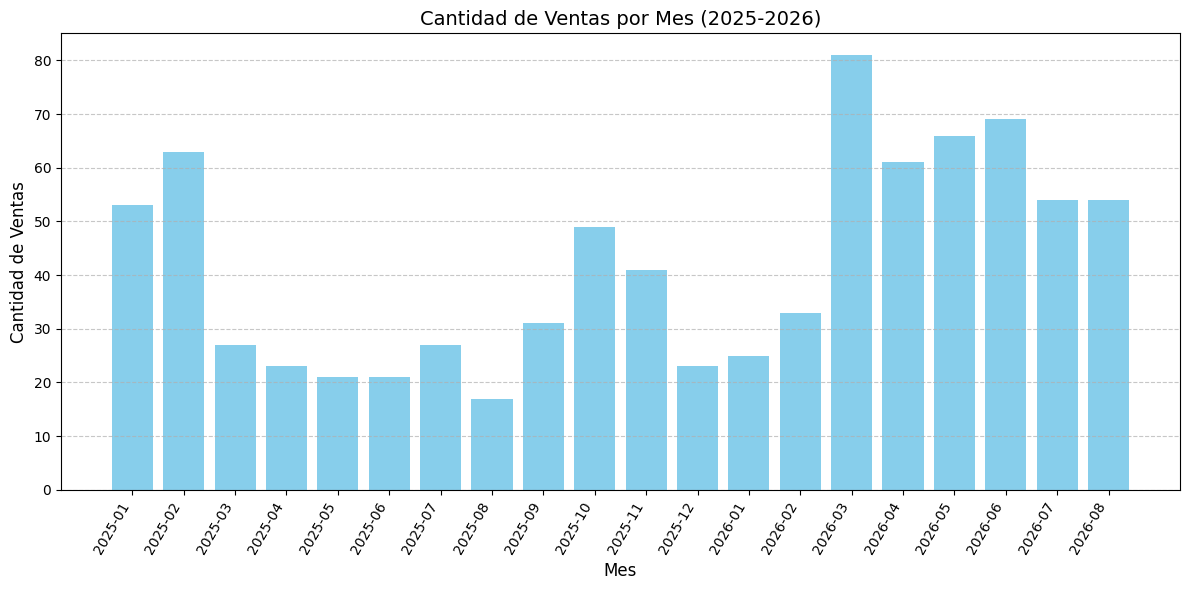

In [78]:
# Se grafica el resultado:

plt.figure(figsize=(12, 6)) # Aumentar el tamaño de la figura para mejor visualización
plt.bar(ventas_por_mes.index.astype(str), ventas_por_mes.values, color='skyblue') # Convertir el índice a string y aplicar un color
plt.xlabel('Mes', fontsize=12) # Aumentar tamaño de fuente del label
plt.ylabel('Cantidad de Ventas', fontsize=12) # Aumentar tamaño de fuente del label
plt.title('Cantidad de Ventas por Mes (2025-2026)', fontsize=14) # Aumentar tamaño de fuente del título
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotar más las etiquetas y a
plt.yticks(fontsize=10) # Aumentar tamaño de fuente de las etiquetas del eje y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir una cuadrícula sutil en el eje y
plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

##### 4.1.1.1 Conclusiones:

Con los resultados obtenidos al momento de segmentar la ventas obtenidas por mes a lo largo del tiempo, en una impresión inicial se puede percibir la siguiente información:

* **Frecuencía de ventas:** Los meses con mayor volumen de ventas suelesn ser los correspondientes al Q1 y al Q4, presentando una caida en el flujo de ventas en el mes de Diciembre, tomando como referencía el año 2025. No obstante, al reisar la frecuencia de ventas que hubo en el 2026, esta tendencia se revirtio, mostrando mayor volumen de ventas durante el Q2 y Q3, superando así mos meses correspondientes del ciclo pasado.

* **Preriodicidad y Festivos:** Durante el 2025, los meses con un desempeño no tan alentador fueron los meses correspondientes a "meses vacacionales" o "Verano", el producto comercializado en ese momento o la estrategía implementada no fueron los optimos para esas fechas, sin embargo, el plan de trabajo el cual se llevo acabo para las vacaciones de semana santa y fechas de vacaciones de verano fueron las optimas.

Estos son los comentarios vertidos hasta el momento, aun falta analizar más información para obtener resultados mas completos.

#### 4.1.2 Visualización de Ventas por Canal a lo Largo del Tiempo (Gráfica de Líneas)

La siguiente gráfica de líneas muestra la evolución de las ventas de cada canal mes a mes. Esto es útil para identificar tendencias, picos o caídas en el rendimiento de cada canal individualmente.

In [79]:
# Se procede a mostrar las ventas que hubo por canal de ventas por mes

ventas_por_canal = df_ventas.groupby(['cliente', 'mes_año']).size().unstack(fill_value=0)
print('Cantidad de ventas por canal:')
print(ventas_por_canal)

Cantidad de ventas por canal:
mes_año  2025-01  2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  \
cliente                                                                  
2808          13       12        6       22       11       11       19   
2814           8        1        1        1        0        1        0   
2917          32       50       20        0       10        9        8   
3093           0        0        0        0        0        0        0   

mes_año  2025-08  2025-09  2025-10  2025-11  2025-12  2026-01  2026-02  \
cliente                                                                  
2808           6       10       21       14        9       20       11   
2814           1        2        2        0        2        1        0   
2917          10       19       26       27       12        4       22   
3093           0        0        0        0        0        0        0   

mes_año  2026-03  2026-04  2026-05  2026-06  2026-07  2026-08  
cliente         

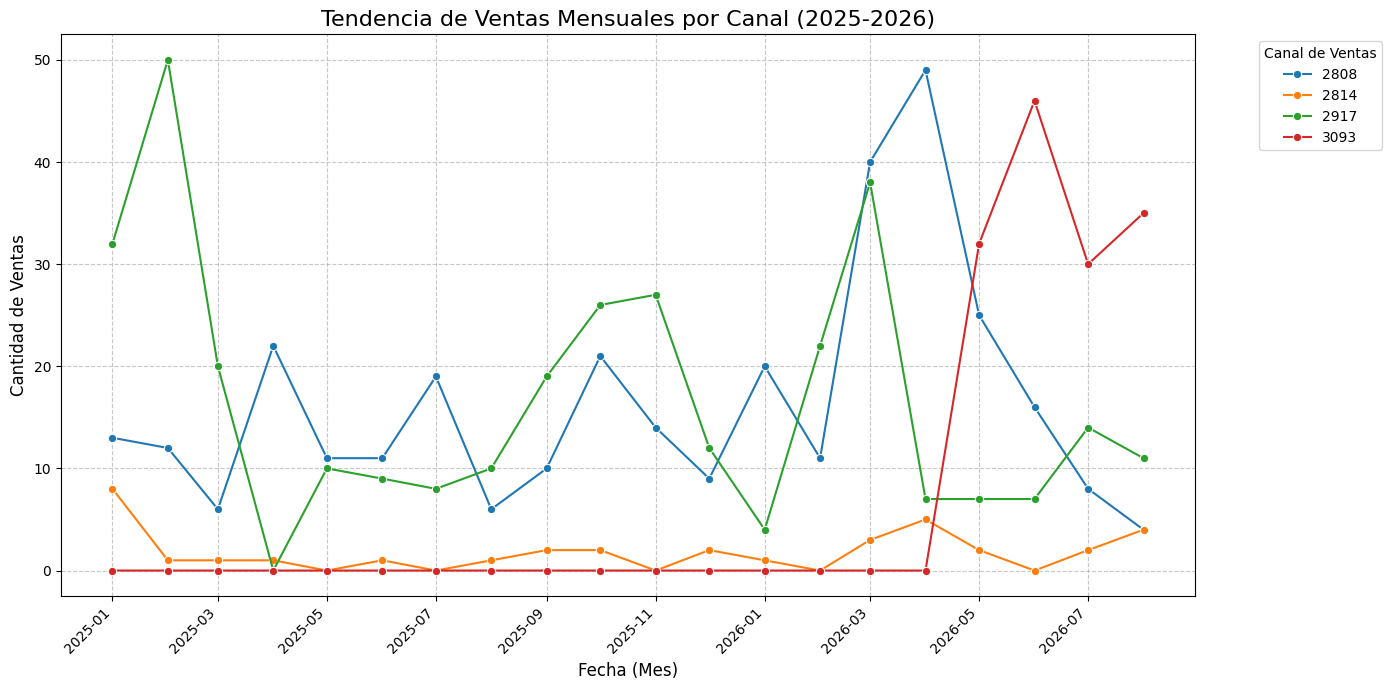

In [80]:
# Transformar el DataFrame ventas_por_canal a formato 'long' para Seaborn
ventas_por_canal_long = ventas_por_canal.stack().reset_index()
ventas_por_canal_long.columns = ['cliente', 'mes_año', 'cantidad_ventas']

# Convertir 'mes_año' de Period a datetime para un correcto ordenamiento en el eje X
ventas_por_canal_long['mes_año'] = ventas_por_canal_long['mes_año'].dt.to_timestamp()

plt.figure(figsize=(14, 7)) # Aumentar el tamaño de la figura
sns.lineplot(data=ventas_por_canal_long, x='mes_año', y='cantidad_ventas', hue='cliente', marker='o')

plt.title('Tendencia de Ventas Mensuales por Canal (2025-2026)', fontsize=16) # Título más descriptivo
plt.xlabel('Fecha (Mes)', fontsize=12)
plt.ylabel('Cantidad de Ventas', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura
plt.grid(True, linestyle='--', alpha=0.7) # Añadir cuadrícula para facilitar la lectura
plt.legend(title='Canal de Ventas', bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.tight_layout() # Ajustar el diseño
plt.show()

##### 4.1.2.1 Conclusiones:

Al visualizar el resultado obtenido podemos llegar a la siguiente conclusión:

* **Resultados sostenidos:** De los 4 canales de ventas actuales, 3 se han mantenido a lo largo del tiempo, pero los que mas han presentado resultados sostenidos a lo largo del tiempo son:

    * 2808
    * 2917

  Esos dos canales se han mantenido activos y constantes desde Enero 2025 hasta la fecha, con altos y bajos, perose han mantenido firmes.

* **Peor desempeño:** Por otro lado, el canal con el peor desempeños hasta el momento es el 2814, este si bien, también ha estado desde el comienzo del periodo a análizar de este DataFrame, es el que peor desempeño ha mostrado a lo largo del tiempo.

* **Mejor arranque sostenido:** Si bien el canal 3093 ha sido agregado recientemente y solo ha estado activo por 4 meses, hasta el momento ha sido el canal con el mejor resultado por un periodo prolongado sostenido por racha mensual que los otros 3.

* **Patrón Bajísta:** Un dato a destacar es que, al momento en el que se introdujo el nuevo canal de venta, sistematicamente los otros 2 comenzaron con una racha bajísta prolongada lo cual es un foco rojo el cual puede ser grave si se mantiene de esa misma manera por un mayor tiempo.

Si bien la introducción de un nuevo canal siempre da una cierta ventaja competititva "abriendo paso a nuevos mercados y nuevos segmentos", cabe resaltar que esto no puede ser motivo para descuidar la atención ni el focus en los otros canales consolidados a lo largo del tiempo.

Los nuevos mercados sirven para epandir, pero los canales que te ayudaron a llegar a donde estas son impotantes para mantener una base solida.

#### 4.1.3 Visualización de Ventas por Producto a lo Largo del Tiempo (Gráfica de Líneas)

La siguiente gráfica de líneas muestra la evolución de las ventas de cada producto mes a mes. Esto es útil para identificar qué productos tienen un rendimiento constante, cuáles están creciendo o disminuyendo, y cuáles son más populares en ciertos periodos.

In [81]:
# Se procede a mostrar las ventas que hubo por canal de ventas por mes

ventas_por_producto = df_ventas.groupby(['artículo', 'mes_año']).size().unstack(fill_value=0)
print('Cantidad de ventas por canal:')
print(ventas_por_producto)

Cantidad de ventas por canal:
mes_año   2025-01  2025-02  2025-03  2025-04  2025-05  2025-06  2025-07  \
artículo                                                                  
67000          11        4        1        4        1        0        6   
67001           0        0        1        0        0        0        1   
67002           4        9        3        6        5        1        0   
67003           5       11        4        0        5        0        2   
67004           5       12        4        1        3        1        0   
6712Z           0        0        0        0        0        0        0   
6713F           0        0        0        0        0        0        0   
6713H           0        0        0        0        0        0        0   
6713J           0        0        0        0        0        0        0   
6713M           0        0        0        0        0        0        0   
6713N           0        0        0        0        0        0        

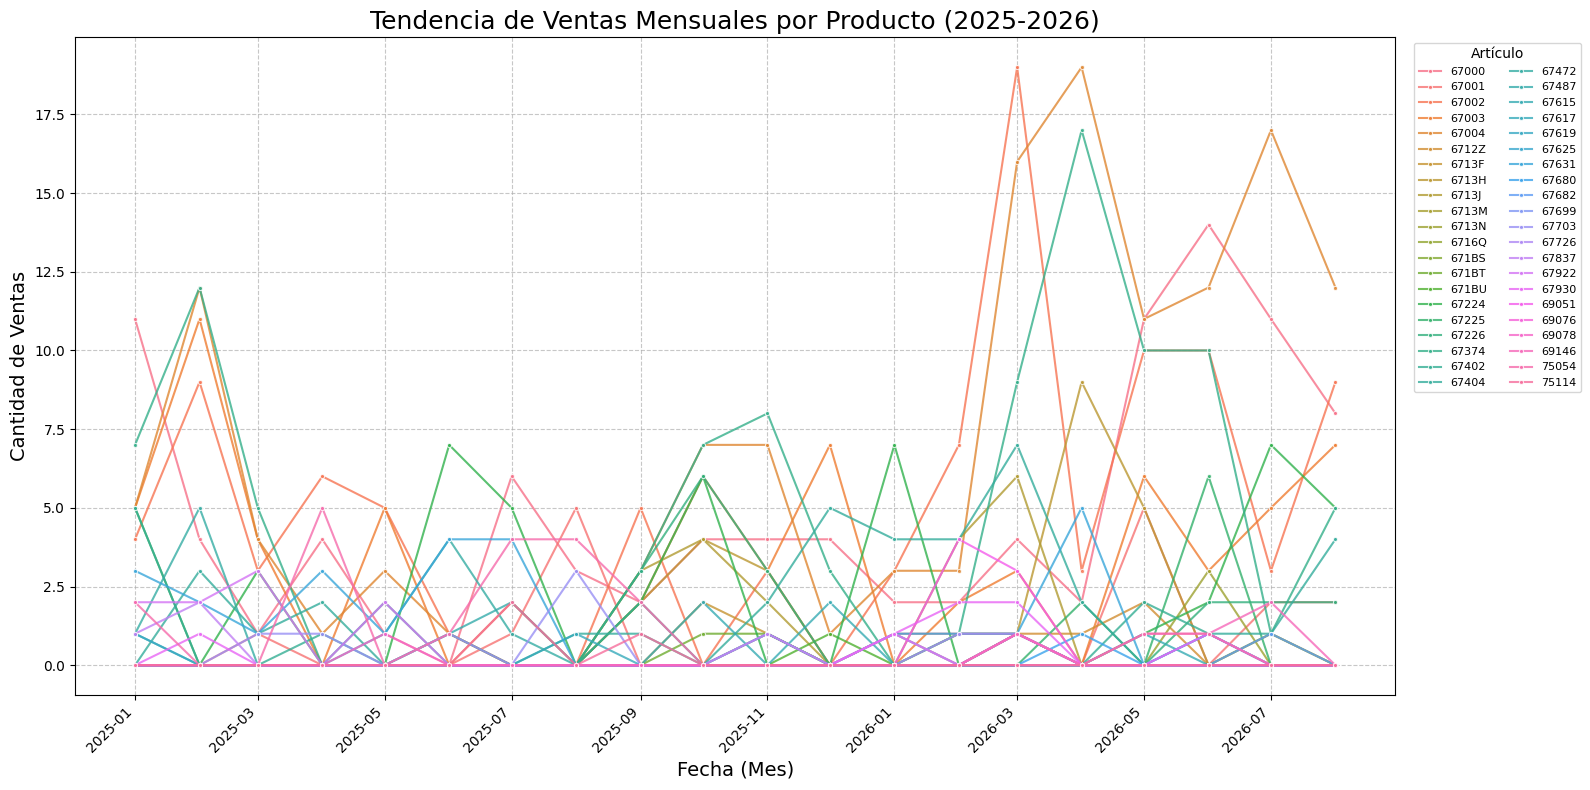

In [82]:
# Calcular las ventas por producto y mes
ventas_por_producto = df_ventas.groupby(['artículo', 'mes_año']).size().unstack(fill_value=0)

# Transformar el DataFrame ventas_por_producto a formato 'long' para Seaborn
ventas_por_producto_long = ventas_por_producto.stack().reset_index()
ventas_por_producto_long.columns = ['articulo', 'mes_año', 'cantidad_ventas']

# Convertir 'mes_año' de Period a datetime para un correcto ordenamiento en el eje X
ventas_por_producto_long['mes_año'] = ventas_por_producto_long['mes_año'].dt.to_timestamp()

# Dado que hay muchos artículos, no mostraremos la leyenda directamente en el gráfico,
# ya que saturaría la visualización. En su lugar, se puede analizar la tendencia general
# y luego filtrar por productos específicos si se desea.

plt.figure(figsize=(16, 8)) # Aumentar el tamaño de la figura
sns.lineplot(data=ventas_por_producto_long, x='mes_año', y='cantidad_ventas', hue='articulo', marker='.', linewidth=1.5, alpha=0.8)

plt.title('Tendencia de Ventas Mensuales por Producto (2025-2026)', fontsize=18) # Título más descriptivo
plt.xlabel('Fecha (Mes)', fontsize=14)
plt.ylabel('Cantidad de Ventas', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotar etiquetas para mejor lectura
plt.yticks(fontsize=10) # Ajustar tamaño de fuente del eje Y
plt.grid(True, linestyle='--', alpha=0.7) # Añadir cuadrícula para facilitar la lectura
plt.legend(title='Artículo', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, fontsize=8) # Leyenda fuera del gráfico con dos columnas
plt.tight_layout() # Ajustar el diseño
plt.show()

##### 4.1.3.1 Conclusiones:

Al analizar la gráfica de tendencia de ventas mensuales por producto, podemos extraer las siguientes observaciones:

*   **Diversidad y fragmentación:** Se observa una gran cantidad de artículos, lo que sugiere una cartera de productos diversa. Sin embargo, la mayoría de los productos muestran volúmenes de ventas bajos y fluctuantes a lo largo del tiempo, indicando que el mercado podría estar fragmentado o que la demanda está dispersa entre muchos productos.

*   **Productos con picos esporádicos:** Algunos productos, como `67000`, `67002`, `67003`, `67004`, `67224`, `67374` y `67922` muestran picos de venta en meses específicos, especialmente alrededor de marzo a mayo de 2026. Esto podría indicar campañas de marketing exitosas, estacionalidad o promociones para esos artículos en particular.

*   **Rendimiento sostenido de pocos productos:** Muy pocos artículos parecen mantener una presencia constante en las ventas mensuales, aunque con variaciones. Artículos como `67000`, `67002` y `67374` se mantienen activos en varios meses, sugiriendo una demanda más estable o estrategias de venta continuas.

*   **Productos con bajo o nulo movimiento:** Una parte significativa de los artículos registra ventas nulas o muy esporádicas a lo largo del periodo analizado, lo que podría indicar productos de nicho, nuevos lanzamientos que aún no despegan, o productos con baja rotación. Se puede observar que el producto `67922` tuvo un pico significativo en marzo de 2026 y luego disminuyó considerablemente.

*   **Necesidad de un análisis más profundo:** Dada la cantidad de productos, una visualización más detallada o un análisis de los "top N" productos más vendidos sería beneficioso para comprender mejor los impulsores de venta y las áreas de oportunidad. El patrón general no muestra una dominancia clara de un solo producto, sino una contribución variable de varios.

### 4.2 Resultados de Canales de Venta

En el presente punto se procedera a visualizar los resultados obtenidos por cada canal de venta, su rendimiento anual y el promedio de rendimiento mensual.

Dado a que uno de los cuatro canales se acaba de ingresar resientemente, se procederea a realizar un promedio de venta mensual para obtener el desempeño obtenido en promedio.

#### 4.2.1 Visualización de resultados totales

[Se procede a mostrar el resultado total de cada canal en el periodo de tiempo total del DF:]

In [83]:
# Se muestra las ventas totales obtenidas por cada canal

ventas_por_canal = df_ventas.groupby(['cliente']).size()
print('Cantidad de ventas por canal:')
print(ventas_por_canal)

Cantidad de ventas por canal:
cliente
2808    327
2814     36
2917    333
3093    143
dtype: int64


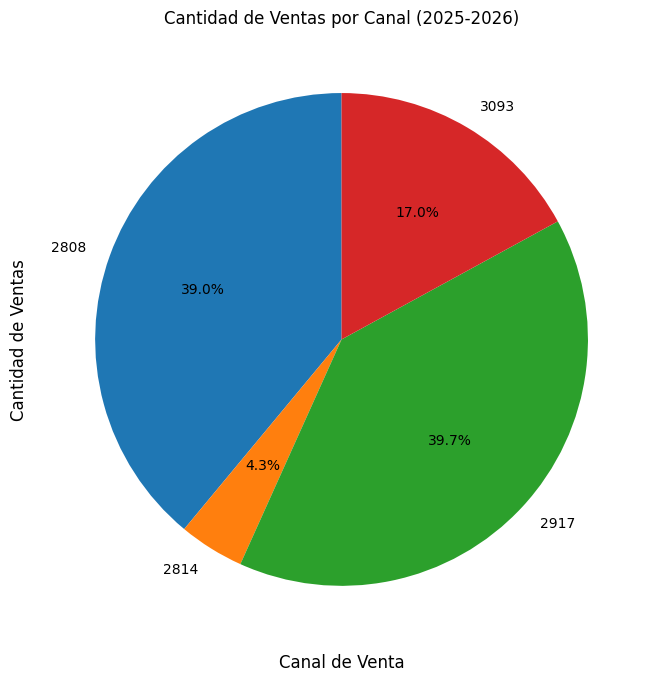

In [84]:
# Se genera una grafica de pastel para mostrar los resultados

plt.figure(figsize=(8, 8)) # Aumentar el tamaño de la figura
plt.pie(ventas_por_canal, labels=ventas_por_canal.index, autopct='%1.1f%%', startangle=90)
plt.xlabel('Canal de Venta', fontsize=12) # Aumentar tamaño de fuente del label
plt.ylabel('Cantidad de Ventas', fontsize=12) # Aumentar tamaño de fuente del label
plt.title('Cantidad de Ventas por Canal (2025-2026)'),
plt.show()

##### 4.2.1.1 Conclusiones:

Dando un vistazo inicial sobre los resultados obtenidos por canal a lo largo del tiempo, se puede percibir los siguientes datos:

* **Canal con mayor venta:** El canal que mayor flujo de venta que ha presentado a lo largo del tiempo es el 2917, este se posiciona con 5 ventas o un .7% por encima de su predecesor el cual es el canal 2808. Esto es sumando los resultados obtenidos del acumulado de 20 meses.

* **Canal con menor venta:** El canal que a mostrado un desempeño no optimo es el 2814, tomando en cuenta que este canal ha estado presentando ventas desde el inicio del periodo hasta la fecha, presenta resultados no favorables, en este caso se tiene que reevaluar la estrategía a seguir para así poder mejorar los resultados, ya sea replanteando la estrategía comercial, aplicando estrategias de marketing o lo que considere mas conveniente el equipo de planeación y comercial para subir los numeros.

* **Canal con resultados sorpresivos:** El canal que ha mostrado resultados sobresalientes es el 3039, con solo 5 meses en operaciones ha dado pasos agigantados llegando casí al 50 porcientos de los resultados obtenidos de los canales top en tan solo 5 meses. Ha presentado exelentes resultados, puede ser por el tratamiento de su estrategía actual o la implementación de la experiencia acumulada de estos años lo que le dio el resultado.

Notas: Cabe resaltar que se retoma el punto mencionado en las conclusiones vertidas en el punto 4.1.2.1 el cual se hace referencia a no descuidar los canales que llevaron al exito, es bueno tener mas canales de ventas pero se tiene que procurar mantener la estrategia en los que llevaron a la empresa en la posición en la que se enuentra.

#### 4.2.2 Visualización de rendimiento promedio

[Se procedera a realiar el calculo del rendimiento promedio mensual de cada canal para mantener bajo al mismo nivel a los 4 y tener una visión mas clara sobre los resultados, descartando el factor de "mayores resultados por acumulación a lo largo del tiempo":]

In [85]:
# Se obtiene el promedio de venta mensual por canal

if 'mes_año' not in df_ventas.columns:
    df_ventas['mes_año'] = df_ventas['fecha_emisión'].dt.to_period('M')

# Calcular las ventas mensuales por cada canal
ventas_mensuales_por_canal = df_ventas.groupby(['cliente', 'mes_año']).size().reset_index(name='cantidad_ventas_mes')

# Calcular el promedio de ventas mensuales por cada canal
promedio_ventas_mensuales_por_canal = ventas_mensuales_por_canal.groupby('cliente')['cantidad_ventas_mes'].mean()

print('Promedio de ventas mensuales por canal:')
print(promedio_ventas_mensuales_por_canal)

Promedio de ventas mensuales por canal:
cliente
2808    16.350000
2814     2.400000
2917    17.526316
3093    35.750000
Name: cantidad_ventas_mes, dtype: float64


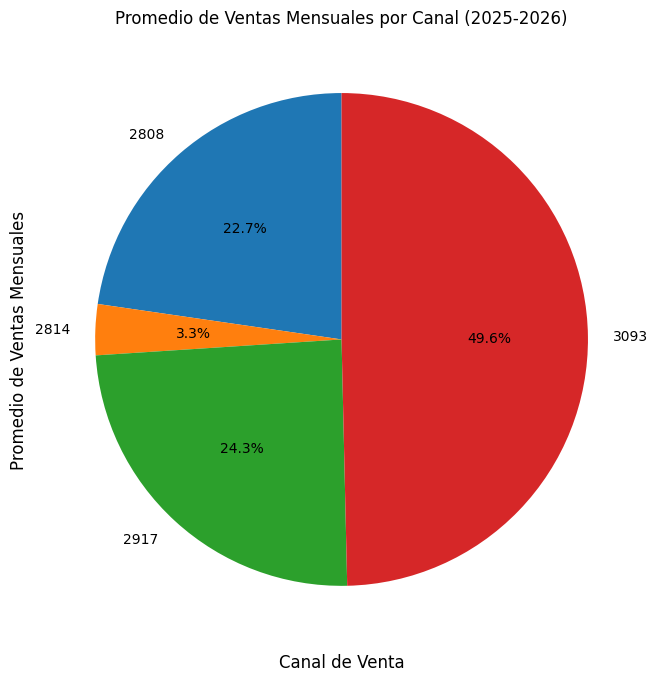

In [86]:
# Se procede a generar un grafico pastel para la visualización de los resultados

plt.figure(figsize=(8, 8)) # Aumentar el tamaño de la figura
plt.pie(promedio_ventas_mensuales_por_canal, labels=promedio_ventas_mensuales_por_canal.index, autopct='%1.1f%%', startangle=90)
plt.xlabel('Canal de Venta', fontsize=12) # Aumentar tamaño de fuente del label
plt.ylabel('Promedio de Ventas Mensuales', fontsize=12) # Aumentar tamaño de fuente del label
plt.title('Promedio de Ventas Mensuales por Canal (2025-2026)'),
plt.show()


##### 4.2.2.1 Conclusiones:

Al visualizar los resultados obtenidos, se puede llegar a las siguientes conclusiones:

* **Cambio en el canal con mayor rendimiento:** Al obtener los resultados de ventas promedio por mes, hubo un cambio en el reacomodo del canal con mejores resultados, posicionano a 3039 en primer lugar.

* **Resultados similares:** Se alcana a apreciar que, la tendencia que hubo entre los canales 2917 y 2808 se mantuvo estatica, manteniendo la tendencia que había en un inicio colocando al primero y al segundo respectivamente en la misma posiión. Por otra parte, 2814 mantiene encabezando el primer lugar como el canal con mayores requerimientos a implementar estretegías de mejora.

Al quitar el factor de acumulación en el tiempo y enfocnandonos en el promedio, podemos quitarle esa ventaja a los canales con mayor tiempo, para poder así apreciar los resultados en igualdad de condiciones aparente a todos los canales. Sin embargo, cabe resaltar que la estrategía implementada para el canal 3039 pudo haber sido influida por la epxperiencia acumulada a lo largo del tiempo, lo cual si bien, no le da ventaja por ventas acumuladas, si que le da en algo que no se puede medir con certeza u objetividad, y es, la experiencia acumulada en la gestión del negocio lo cual le permite a la administración la implementación de la formula de exito que tuvieron los otros dos canales para poder levantar este en menor tiempo.

## 5.0 Conclusiones finales

A lo largo de este análisis, se ha llevado a cabo un estudio exhaustivo de los datos de ventas de la empresa E-Commerce para el periodo de "Enero 2025 - Agosto 2026", con el objetivo de proporcionar una base sólida para la planificación estratégica de los Q3 y Q4 de 2026. A continuación, se presentan las conclusiones finales:

*   **Reporte de Ventas Anuales por Mes:**
    *   Se observó una clara estacionalidad en las ventas, con un cambio notable en el comportamiento entre 2025 y 2026. Mientras que en 2025 los picos se concentraron en Q1 y Q4, en 2026 se desplazaron hacia Q2 y Q3, lo cual sugiere una adaptación exitosa de las estrategias comerciales durante periodos vacacionales.
    *   La capacidad de revertir la tendencia bajista en los meses de verano de 2025 a un incremento significativo en 2026 destaca la efectividad de las nuevas implementaciones estratégicas.

*   **Rendimiento de los Canales de Venta:**
    *   Al analizar las ventas totales acumuladas, el canal **2917** mostró el mayor volumen, seguido de cerca por el **2808**. Ambos han mantenido una presencia constante y resultados sostenidos a lo largo de todo el periodo.
    *   El canal **2814** ha sido consistentemente el de menor rendimiento, lo que indica la necesidad urgente de reevaluar su estrategia, ya sea mediante la optimización de procesos, campañas de marketing o la redefinición de su propuesta de valor.
    *   Un hallazgo crucial fue la emergencia del canal **3093**. A pesar de su reciente introducción (solo 4 meses de operación), su promedio de ventas mensuales (**35.75**) lo posiciona como el canal más eficiente y con mayor rendimiento promedio, superando significativamente a los demás. Esto revela un potencial enorme y sugiere que se ha aplicado una fórmula de éxito o experiencia acumulada que ha acelerado su tracción.
    *   Es fundamental destacar la observación de un "patrón bajista" en los canales consolidados (2808 y 2917) tras la introducción del 3093. Si bien la expansión a nuevos canales es vital para el crecimiento, es imperativo asegurar que esto no se traduzca en el descuido o canibalización de los canales existentes que han sido pilares del negocio.

*   **Comportamiento de Ventas por Producto:**
    *   La cartera de productos es diversa, aunque la mayoría de los artículos presentan volúmenes de ventas fluctuantes y bajos, indicando un mercado fragmentado. Pocos productos (`67000`, `67002`, `67374`) muestran un rendimiento más sostenido, mientras que otros experimentan picos esporádicos o bajo movimiento.
    *   Este análisis sugiere la necesidad de una estrategia de gestión de inventario y marketing más segmentada, identificando los "productos estrella" y aquellos que requieren mayor impulso o, en su defecto, una revisión de su viabilidad.

En resumen, los objetivos planteados al inicio del proyecto han sido alcanzados, proporcionando una visión clara sobre las tendencias de ventas mensuales y el rendimiento de cada canal. La información generada es una herramienta valiosa para la dirección, permitiendo tomar decisiones informadas para el desarrollo y optimización de las estrategias en los Q3 y Q4 de 2026, buscando maximizar la eficiencia y el crecimiento sostenido de la empresa.